In [2]:
import importlib
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import db_config

from db_config import get_database_url, get_database_render_url
from sqlalchemy import create_engine

In [101]:
pd.set_option('display.float_format', '{:.3f}'.format)

In [4]:
engine_local = create_engine(get_database_url(), pool_pre_ping=True)
df = pd.read_sql(
    "SELECT * FROM public.pollen_by_date_time",
    engine_local
)

df.head()

,fdate,ftime,camps_point_id,analysis_time,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
0,2026-07-15,19:00:00,4,2026-07-15,0.0000002921,0.0001068115,17.1409301758,0.3877716064,0.0000610352,0.0000079870,17.5288772583
1,2026-07-15,19:00:00,3,2026-07-15,0.0000002850,0.0001220703,14.2945556641,0.4591064453,0.0000610352,0.0000083447,14.7538537979
2,2026-07-15,19:00:00,2,2026-07-15,0.0000002708,0.0001373291,12.6982421875,0.4486694336,0.0000610352,0.0000083447,13.1471185684
3,2026-07-15,19:00:00,1,2026-07-15,0.0000002370,0.0001525879,17.3486328125,0.3596038818,0.0000610352,0.0000068545,17.7084579468
4,2026-07-15,16:00:00,11,2026-07-15,0.0000005757,0.0000000000,7.3946533203,0.0210418701,0.0000000000,0.0000009537,7.4156966209


In [5]:
df['fdate'] = pd.to_datetime(df['fdate'], format='%Y-%m-%d')
df['ftime'] = pd.to_datetime(df['ftime'], format='%H:%M:%S').dt.time
df['analysis_time'] = pd.to_datetime(df['analysis_time'], format='%Y-%m-%d')
df.head(24)

,fdate,ftime,camps_point_id,analysis_time,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
0,2026-07-15,19:00:00,4,2026-07-15,0.0000002921,0.0001068115,17.1409301758,0.3877716064,0.0000610352,0.0000079870,17.5288772583
1,2026-07-15,19:00:00,3,2026-07-15,0.0000002850,0.0001220703,14.2945556641,0.4591064453,0.0000610352,0.0000083447,14.7538537979
2,2026-07-15,19:00:00,2,2026-07-15,0.0000002708,0.0001373291,12.6982421875,0.4486694336,0.0000610352,0.0000083447,13.1471185684
3,2026-07-15,19:00:00,1,2026-07-15,0.0000002370,0.0001525879,17.3486328125,0.3596038818,0.0000610352,0.0000068545,17.7084579468
4,2026-07-15,16:00:00,11,2026-07-15,0.0000005757,0.0000000000,7.3946533203,0.0210418701,0.0000000000,0.0000009537,7.4156966209
5,2026-07-15,18:00:00,15,2026-07-15,0.0000002187,0.0000076294,14.3341979980,0.2377471924,0.0000610352,0.0000039339,14.5720176697
6,2026-07-15,18:00:00,14,2026-07-15,0.0000001739,0.0000076294,9.4556274414,0.5566864014,0.0000000000,0.0000040531,10.0123252869
7,2026-07-15,18:00:00,13,2026-07-15,0.0000001409,0.0000076294,8.5573120117,0.5995178223,0.0000000000,0.0000040531,9.1568412781
8,2026-07-15,18:00:00,12,2026-07-15,0.0000001410,0.0000000000,7.5956420898,0.3442687988,0.0000000000,0.0000029802,7.9399137497
9,2026-07-15,18:00:00,11,2026-07-15,0.0000000745,0.0000000000,3.9669494629,0.1476593018,0.0000000000,0.0000023842,4.1146111488


In [6]:
df.dtypes

fdate             datetime64[s]
ftime                    object
camps_point_id            int64
analysis_time     datetime64[s]
alder_pollen            float64
birch_pollen            float64
grass_pollen            float64
mugwort_pollen          float64
olive_pollen            float64
ragweed_pollen          float64
pollen_total            float64
dtype: object

In [7]:
df_grouped = df.groupby(['fdate', 'camps_point_id'])[
    ['alder_pollen', 'birch_pollen', 'grass_pollen', 'mugwort_pollen', 'olive_pollen', 'ragweed_pollen', 'pollen_total']
].mean()
df_grouped.tail(20)

alder_pollen  birch_pollen  grass_pollen  \
fdate      camps_point_id                                             
2026-07-14 11              0.0000009312  0.0002622604 13.9091453552   
           12              0.0000009500  0.0002708435 12.2699553172   
           13              0.0000009631  0.0002683004 11.4943097432   
           14              0.0000010027  0.0002625783 12.1257400513   
           15              0.0000011080  0.0002832413 13.4090518951   
2026-07-15 1               0.0000008527  0.0002107620 13.3553441366   
           2               0.0000009115  0.0001455943 14.0998210907   
           3               0.0000009485  0.0001414617 14.4673112233   
           4               0.0000009739  0.0001389186 14.7393798828   
           5               0.0000009887  0.0001440048 15.2808030446   
           6               0.0000008558  0.0000979106 10.5202452342   
           7               0.0000008724  0.0001306534 10.7931098938   
           8               0.0000008765  0.0001583099 10.0429642995   
           9               0.0000008610  0.0001678467 10.5515130361   
           10              0.0000008408  0.0001408259 13.0385545095   
           11              0.0000006271  0.0000441869  6.4863039653   
           12              0.0000006394  0.0000473658  7.1798941294   
           13              0.0000006286  0.0000556310  7.4133307139   
           14              0.0000006414  0.0000575384  8.2653649648   
           15              0.0000006571  0.0000664393  9.9927673340   

                           mugwort_pollen  olive_pollen  ragweed_pollen  \
fdate      camps_point_id                                                 
2026-07-14 11                0.2526262601  0.0000505845    0.0000045449   
           12                0.3655881882  0.0000536442    0.0000044679   
           13                0.4238478343  0.0000596841    0.0000042617   
           14                0.3213717143  0.0000582139    0.0000042394   
           15                0.1215376854  0.0000617107    0.0000041872   
2026-07-15 1                 0.2277101676  0.0000483195    0.0000069930   
           2                 0.2977308432  0.0000470479    0.0000076474   
           3                 0.3513021469  0.0000553131    0.0000089034   
           4                 0.2921981017  0.0000540415    0.0000102663   
           5                 0.1579073270  0.0000580947    0.0000122500   
           6                 0.3588568370  0.0000238419    0.0000045268   
           7                 0.6306664149  0.0000277360    0.0000049025   
           8                 0.9994362195  0.0000345707    0.0000057028   
           9                 0.6603942712  0.0000421206    0.0000069216   
           10                0.2786378860  0.0000453790    0.0000083409   
           11                0.0939862728  0.0000156959    0.0000030287   
           12                0.1629614830  0.0000152191    0.0000034372   
           13                0.2416922251  0.0000152191    0.0000039575   
           14                0.1865085761  0.0000185569    0.0000044877   
           15                0.1009062926  0.0000248750    0.0000057115   

                           pollen_total  
fdate      camps_point_id                
2026-07-14 11             14.1620896657  
           12             12.6358732581  
           13             11.9184908271  
           14             12.4474379122  
           15             13.5309399565  
2026-07-15 1              13.5833211342  
           2              14.3977530201  
           3              14.8188200593  
           4              15.0317822695  
           5              15.4389257034  
           6              10.8792290489  
           7              11.4239404003  
           8              11.0425998370  
           9              11.2121249437  
           10             13.3173877597  
           11              6.5803537518  
           12              7.3429222107  
           13  

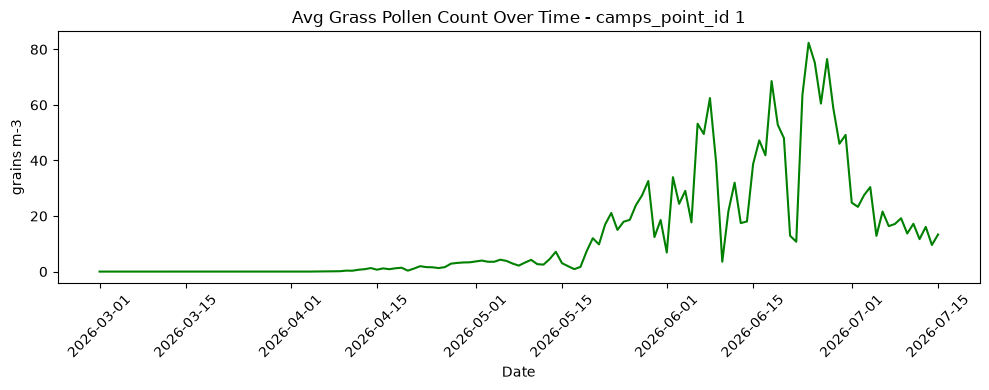

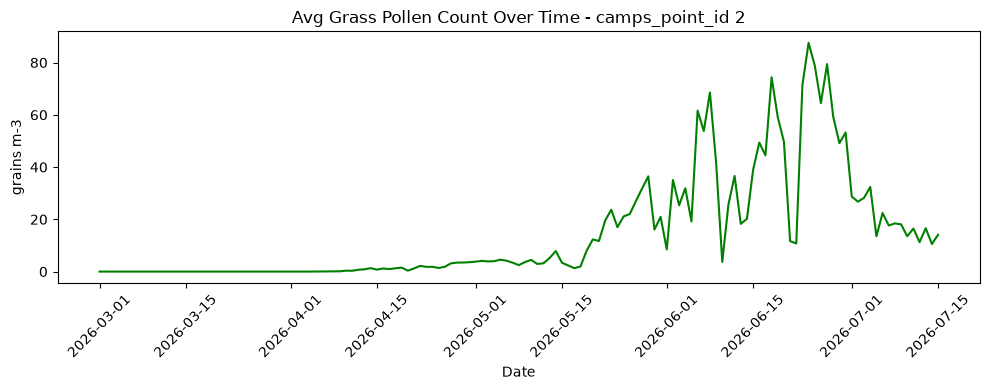

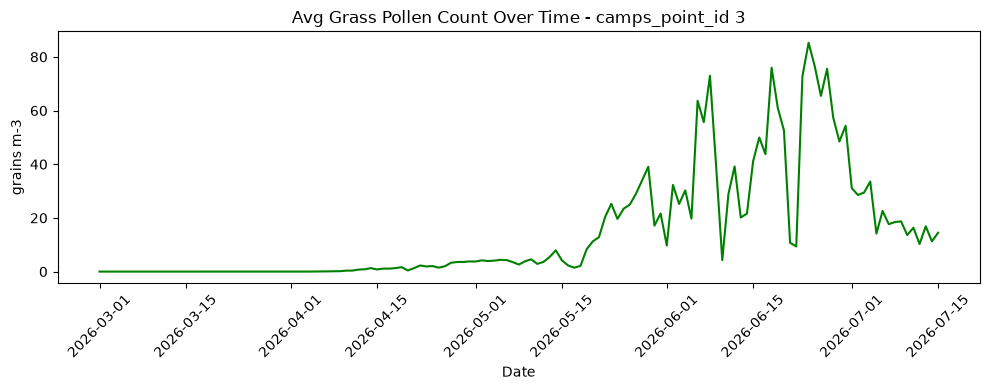

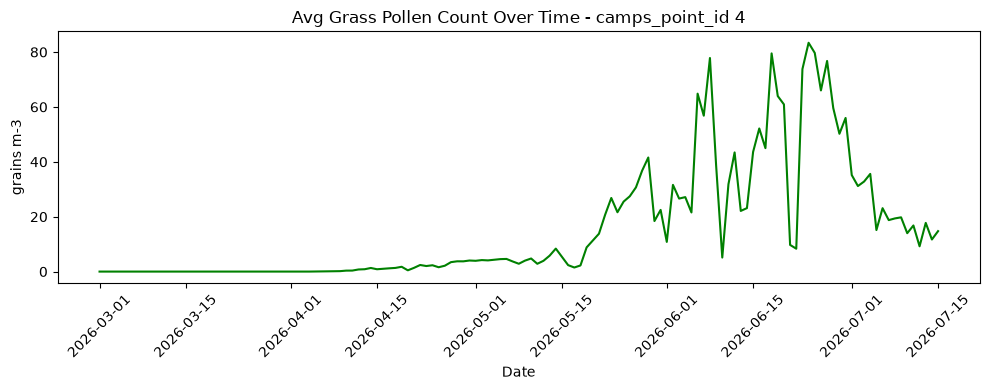

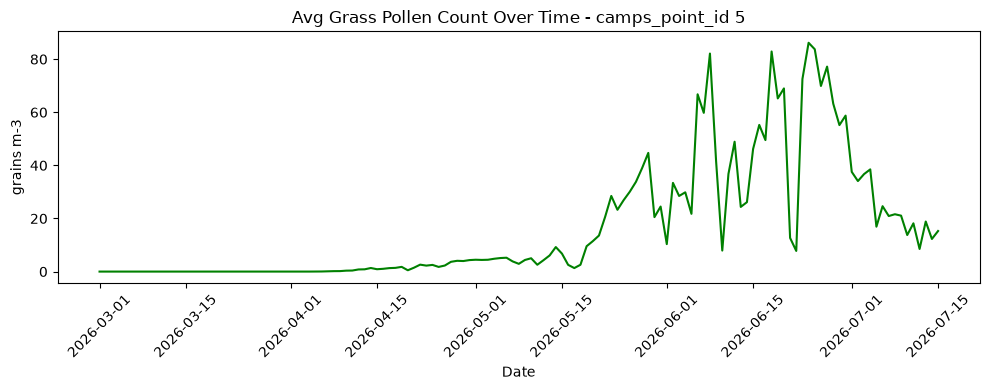

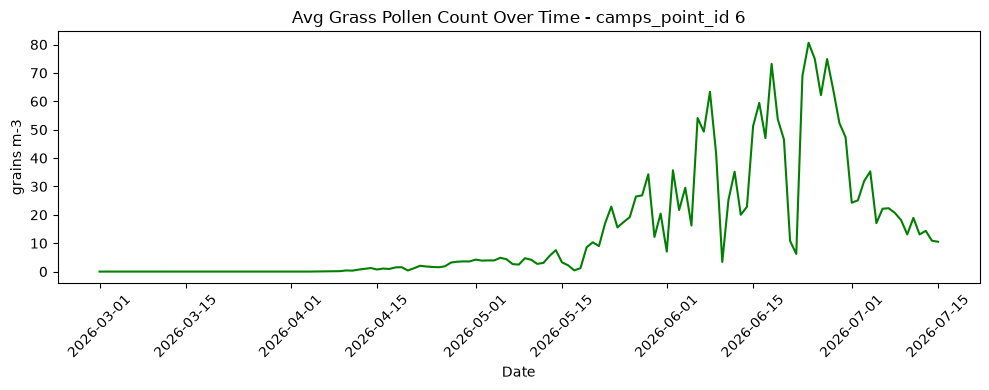

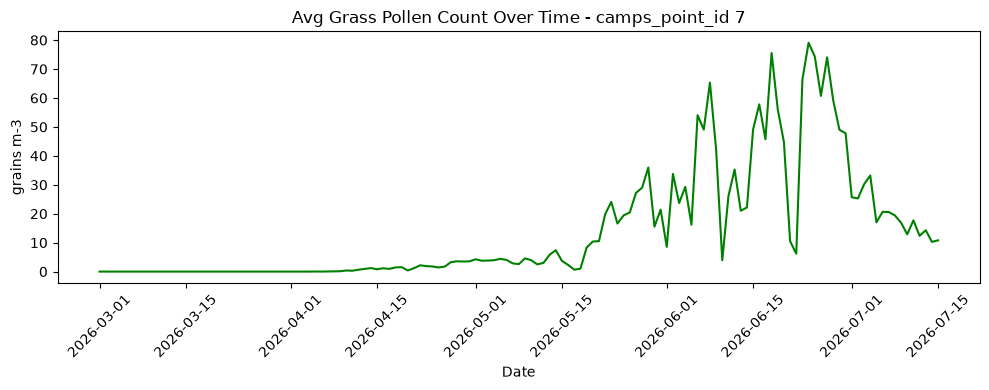

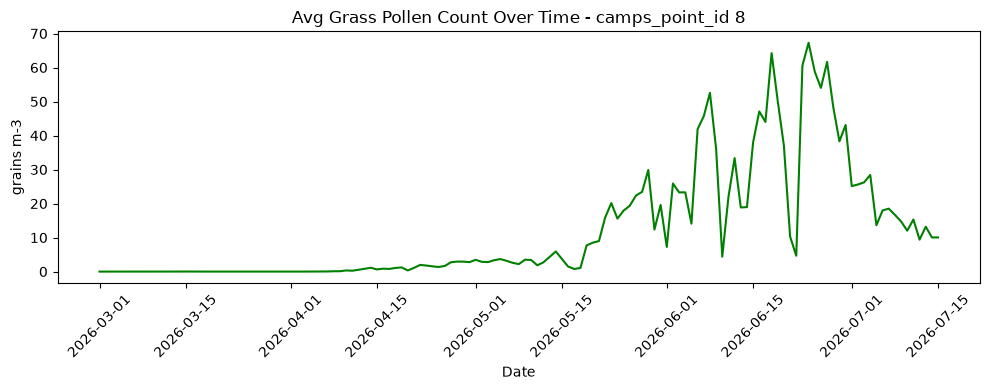

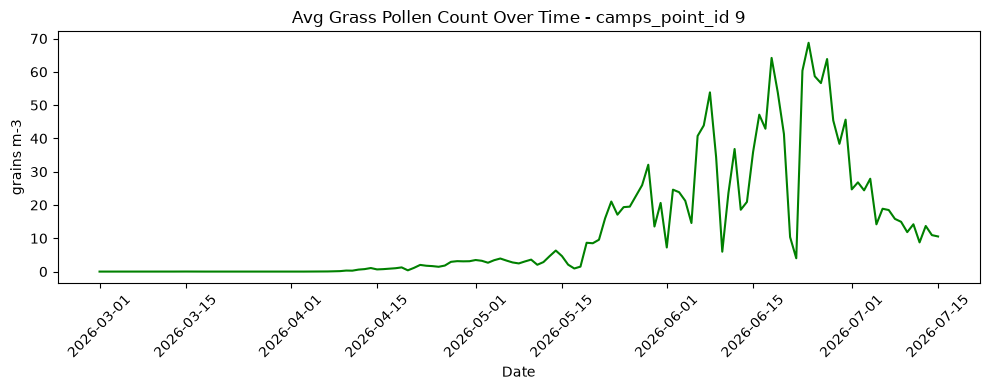

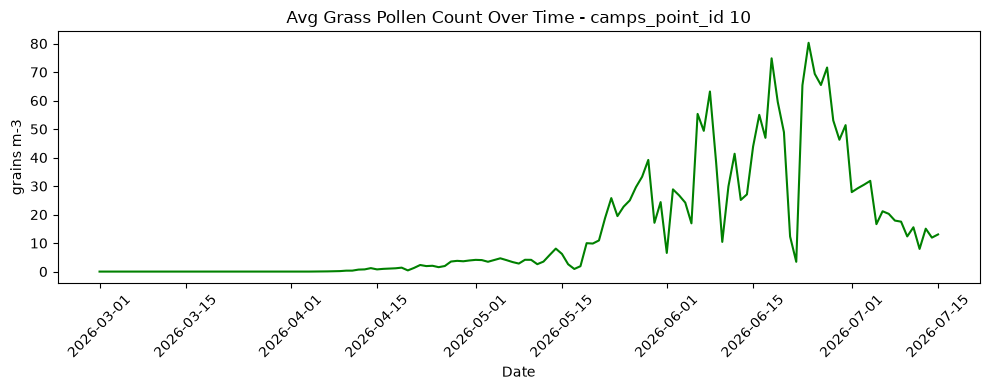

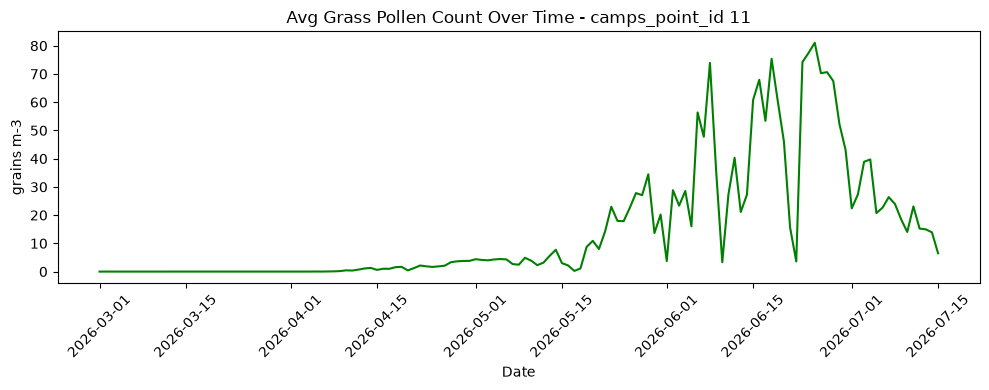

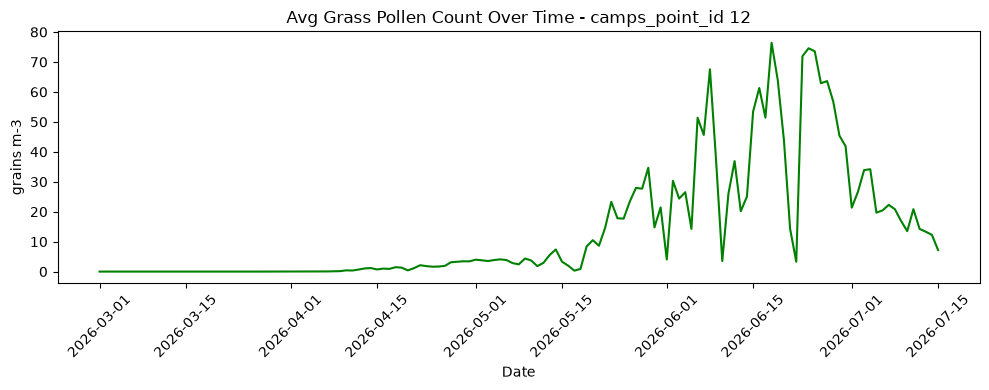

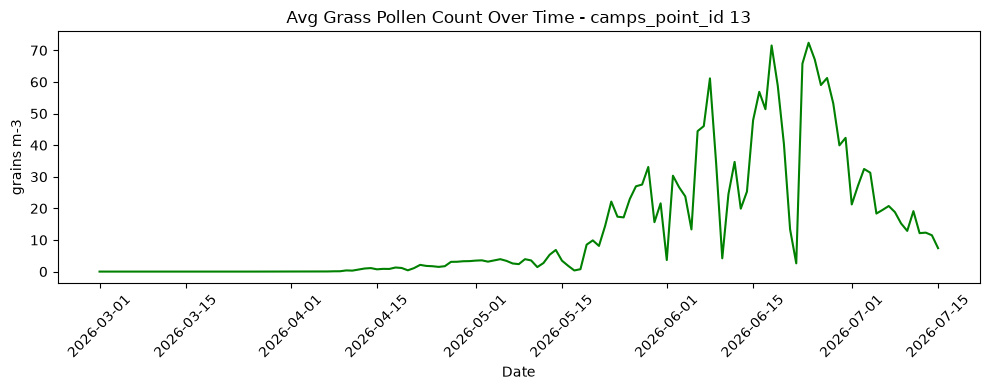

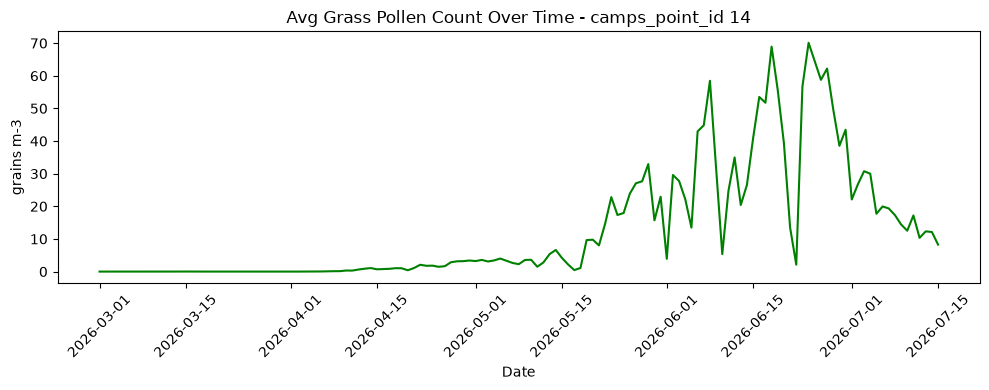

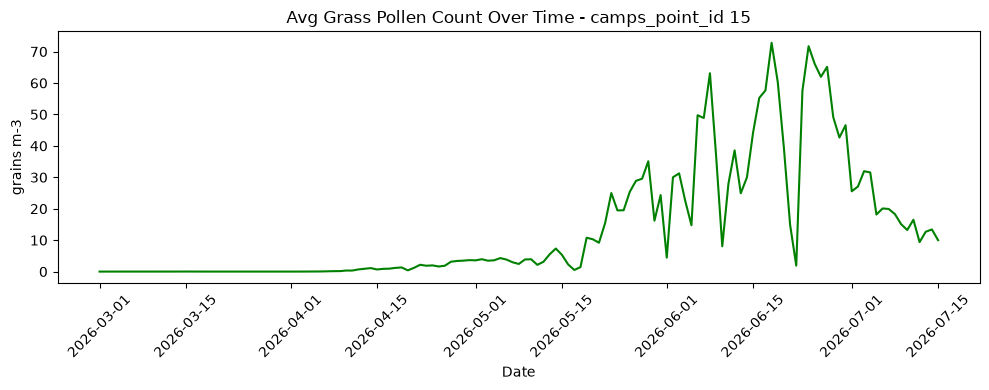

In [8]:
%matplotlib inline

site_ids = sorted(pd.to_numeric(df['camps_point_id'], errors='coerce').dropna().astype(int).unique())

for site_id in site_ids:
    site_series = (
        df_grouped.xs(site_id, level='camps_point_id')['grass_pollen']
        .sort_index()
    )
    plt.figure(figsize=(10, 4))
    plt.plot(site_series.index, site_series.values, color='g')
    plt.title(f"Avg Grass Pollen Count Over Time - camps_point_id {site_id}")
    plt.xlabel("Date")
    plt.xticks(rotation=45)
    plt.ylabel("grains m-3")
    plt.tight_layout()
    plt.show()

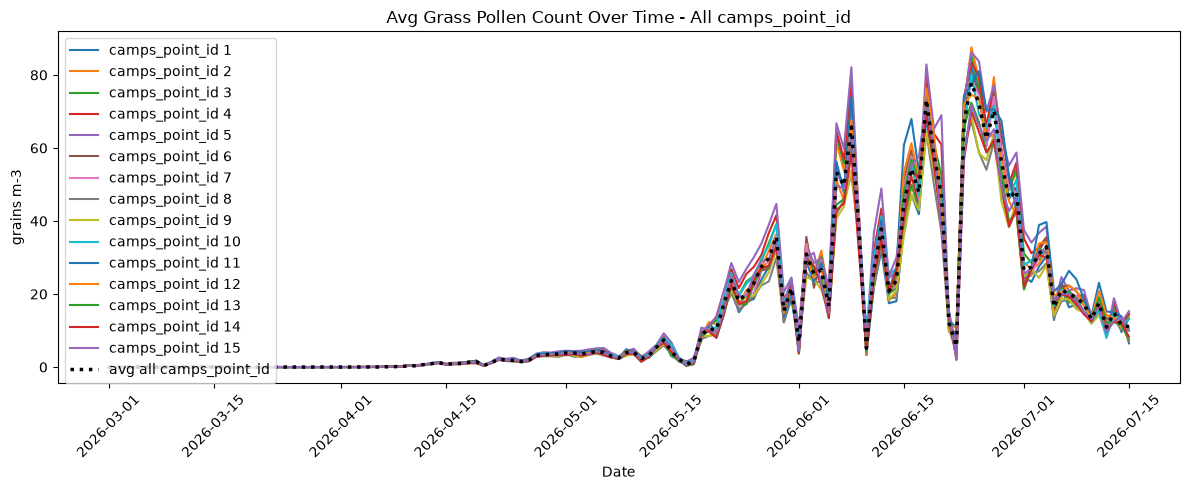

In [9]:
%matplotlib inline

plt.figure(figsize=(12, 5))

overall_avg = (
    df_grouped.groupby(level='fdate')['grass_pollen']
    .mean()
    .sort_index()
)

for site_id in site_ids:
    site_series = (
        df_grouped.xs(site_id, level='camps_point_id')['grass_pollen']
        .sort_index()
    )
    plt.plot(
        site_series.index,
        site_series.values,
        label=f'camps_point_id {site_id}',
        zorder=1
    )

plt.plot(
    overall_avg.index,
    overall_avg.values,
    label='avg all camps_point_id',
    linewidth=2.5,
    color='black',
    linestyle=':',
    zorder=2
)

plt.title('Avg Grass Pollen Count Over Time - All camps_point_id')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.ylabel('grains m-3')
plt.legend(loc='upper left', bbox_to_anchor=(0.0, 1.0))
plt.tight_layout()
plt.show()

In [10]:
df_grouped_time = (
    df.groupby(['fdate', 'ftime'], as_index=False)[
        ['alder_pollen', 'birch_pollen', 'grass_pollen', 'mugwort_pollen', 'olive_pollen', 'ragweed_pollen', 'pollen_total']
    ].mean()
)
df_grouped_time.tail(10)


,fdate,ftime,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
3278,2026-07-15,14:00:00,0.0000004404,0.0001424154,12.0636047363,0.3011225382,0.0000143687,0.0000114759,12.3648957888
3279,2026-07-15,15:00:00,0.0000004869,0.0001383464,10.2424875895,0.1790508270,0.0000722249,0.0000053088,10.4217545191
3280,2026-07-15,16:00:00,0.0000004729,0.0000859578,10.9871470133,0.4875946045,0.0000016530,0.0000031630,11.4748328845
3281,2026-07-15,17:00:00,0.0000003394,0.0000061035,14.5877319336,0.6566375732,0.0000259399,0.0000042041,15.2444058736
3282,2026-07-15,18:00:00,0.0000002584,0.0000066121,15.0131917318,0.7320782979,0.0000325521,0.0000051339,15.7453144391
3283,2026-07-15,19:00:00,0.0000002550,0.0000905355,11.5850504557,0.6528961182,0.0000406901,0.0000051836,12.2380830447
3284,2026-07-15,20:00:00,0.0000002695,0.0000076294,6.9155110677,0.4880503337,0.0000330607,0.0000046531,7.4036068916
3285,2026-07-15,21:00:00,0.0000003233,0.0000000000,4.2956746419,0.3555577596,0.0000019073,0.0000043193,4.6512388865
3286,2026-07-15,22:00:00,0.0000003685,0.0000000000,4.4998107910,0.1223088582,0.0000038147,0.0000039895,4.6221278191
3287,2026-07-15,23:00:00,0.0000003075,0.0000076294,6.6035624186,0.0564717611,0.0000590007,0.0000044713,6.6601056099


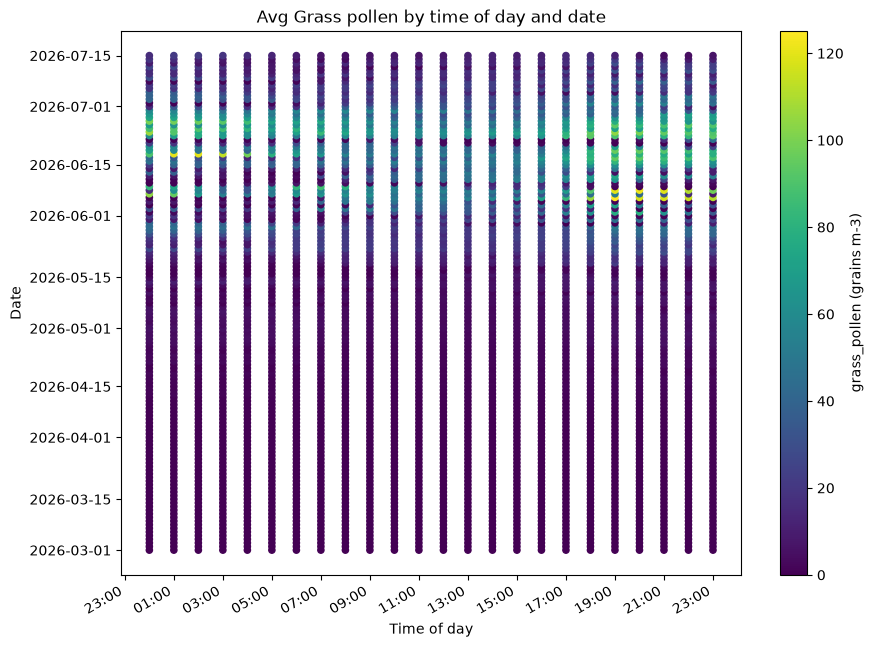

In [11]:
# Scatter plot: x = ftime (time of day), y = fdate (date), color = grass_pollen

ftimes = pd.to_datetime(df_grouped_time['ftime'].astype(str), format='%H:%M:%S', errors='coerce')
fdates = df_grouped_time['fdate']

plt.figure(figsize=(10, 8))
sc = plt.scatter(ftimes, fdates, c=df_grouped_time['grass_pollen'], cmap='viridis', s=20)
plt.colorbar(sc, label='grass_pollen (grains m-3)')
plt.xlabel('Time of day')
plt.ylabel('Date')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.gcf().autofmt_xdate()
plt.title(f'Avg Grass pollen by time of day and date')
plt.show()


In [167]:
engine_render = create_engine(get_database_render_url(), pool_pre_ping=True)
df_synop = pd.read_sql(
    """SELECT * FROM public.synop_data
    ORDER BY date DESC, measurement_hour ASC """,
    engine_render
)

df_synop.head()

,station_id,date,measurement_hour,date_add,date_update,station_name,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure
0,12566,2026-07-16,0,2026-07-16 01:00:32.266317,2026-07-16 01:00:32.263508,Kraków,16.600,1.000,210,98.100,0.000,1021.000
1,12566,2026-07-16,1,2026-07-16 02:00:34.406118,2026-07-16 02:00:34.403562,Kraków,15.600,0.000,0,98.700,0.000,1020.700
2,12566,2026-07-16,2,2026-07-16 03:00:39.208356,2026-07-16 03:00:39.206737,Kraków,16.400,1.000,200,98.100,0.000,1020.900
3,12566,2026-07-16,3,2026-07-16 04:00:23.596945,2026-07-16 04:00:23.594140,Kraków,16.300,1.000,270,98.700,0.000,1020.900
4,12566,2026-07-16,4,2026-07-16 05:00:43.313868,2026-07-16 05:00:43.311293,Kraków,16.000,1.000,30,98.700,0.000,1020.800


In [168]:
df_synop.dtypes

station_id                    int64
date                         object
measurement_hour              int64
date_add             datetime64[us]
date_update          datetime64[us]
station_name                    str
temperature                 float64
wind_speed                  float64
wind_direction                int64
relative_humidity           float64
rainfall_sum                float64
pressure                    float64
dtype: object

In [169]:
df_synop['date'] = pd.to_datetime(df_synop['date'], format='%Y-%m-%d')
df_synop['measurement_hour_dt'] = df_synop['date'] + pd.to_timedelta(df_synop['measurement_hour'], unit='h')
df_synop['measurement_hour'] = df_synop['measurement_hour_dt'].dt.time

df_synop['date_24h_ahead'] = df_synop['measurement_hour_dt'] + pd.Timedelta(hours=24)

In [170]:
df_synop.head(24)

,station_id,date,measurement_hour,date_add,date_update,station_name,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,measurement_hour_dt,date_24h_ahead
0,12566,2026-07-16,00:00:00,2026-07-16 01:00:32.266317,2026-07-16 01:00:32.263508,Kraków,16.600,1.000,210,98.100,0.000,1021.000,2026-07-16 00:00:00,2026-07-17 00:00:00
1,12566,2026-07-16,01:00:00,2026-07-16 02:00:34.406118,2026-07-16 02:00:34.403562,Kraków,15.600,0.000,0,98.700,0.000,1020.700,2026-07-16 01:00:00,2026-07-17 01:00:00
2,12566,2026-07-16,02:00:00,2026-07-16 03:00:39.208356,2026-07-16 03:00:39.206737,Kraków,16.400,1.000,200,98.100,0.000,1020.900,2026-07-16 02:00:00,2026-07-17 02:00:00
3,12566,2026-07-16,03:00:00,2026-07-16 04:00:23.596945,2026-07-16 04:00:23.594140,Kraków,16.300,1.000,270,98.700,0.000,1020.900,2026-07-16 03:00:00,2026-07-17 03:00:00
4,12566,2026-07-16,04:00:00,2026-07-16 05:00:43.313868,2026-07-16 05:00:43.311293,Kraków,16.000,1.000,30,98.700,0.000,1020.800,2026-07-16 04:00:00,2026-07-17 04:00:00
5,12566,2026-07-16,05:00:00,2026-07-16 06:00:52.630454,2026-07-16 06:00:52.629656,Kraków,16.500,1.000,240,98.100,0.000,1020.900,2026-07-16 05:00:00,2026-07-17 05:00:00
6,12566,2026-07-16,06:00:00,2026-07-16 07:00:26.294993,2026-07-16 07:00:26.292989,Kraków,17.000,1.000,340,98.100,2.100,1020.800,2026-07-16 06:00:00,2026-07-17 06:00:00
7,12566,2026-07-16,07:00:00,2026-07-16 08:00:41.787578,2026-07-16 08:00:41.783470,Kraków,17.900,2.000,220,96.800,2.100,1021.100,2026-07-16 07:00:00,2026-07-17 07:00:00
8,12566,2026-07-16,08:00:00,2026-07-16 09:00:53.917618,2026-07-16 09:00:53.914786,Kraków,19.800,1.000,200,81.400,2.100,1020.900,2026-07-16 08:00:00,2026-07-17 08:00:00
9,12566,2026-07-16,09:00:00,2026-07-16 10:00:38.729886,2026-07-16 10:00:38.727627,Kraków,22.100,3.000,210,76.600,2.100,1021.000,2026-07-16 09:00:00,2026-07-17 09:00:00


In [171]:
df_synop_filtered = df_synop[['date', 'date_24h_ahead', 'measurement_hour', 'temperature', 'wind_speed', 'wind_direction', 'relative_humidity', 'rainfall_sum', 'pressure']].copy()
df_synop_filtered.head()

,date,date_24h_ahead,measurement_hour,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure
0,2026-07-16,2026-07-17 00:00:00,00:00:00,16.600,1.000,210,98.100,0.000,1021.000
1,2026-07-16,2026-07-17 01:00:00,01:00:00,15.600,0.000,0,98.700,0.000,1020.700
2,2026-07-16,2026-07-17 02:00:00,02:00:00,16.400,1.000,200,98.100,0.000,1020.900
3,2026-07-16,2026-07-17 03:00:00,03:00:00,16.300,1.000,270,98.700,0.000,1020.900
4,2026-07-16,2026-07-17 04:00:00,04:00:00,16.000,1.000,30,98.700,0.000,1020.800


In [172]:
df_merged = df_synop_filtered.merge(
    df_grouped_time[['fdate', 'ftime', 'grass_pollen']].rename(columns={'fdate': 'date', 'ftime': 'measurement_hour'}),
    on=['date', 'measurement_hour'],
    how='left'
)
df_merged.head()

,date,date_24h_ahead,measurement_hour,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,grass_pollen
0,2026-07-16,2026-07-17 00:00:00,00:00:00,16.600,1.000,210,98.100,0.000,1021.000,NaN
1,2026-07-16,2026-07-17 01:00:00,01:00:00,15.600,0.000,0,98.700,0.000,1020.700,NaN
2,2026-07-16,2026-07-17 02:00:00,02:00:00,16.400,1.000,200,98.100,0.000,1020.900,NaN
3,2026-07-16,2026-07-17 03:00:00,03:00:00,16.300,1.000,270,98.700,0.000,1020.900,NaN
4,2026-07-16,2026-07-17 04:00:00,04:00:00,16.000,1.000,30,98.700,0.000,1020.800,NaN


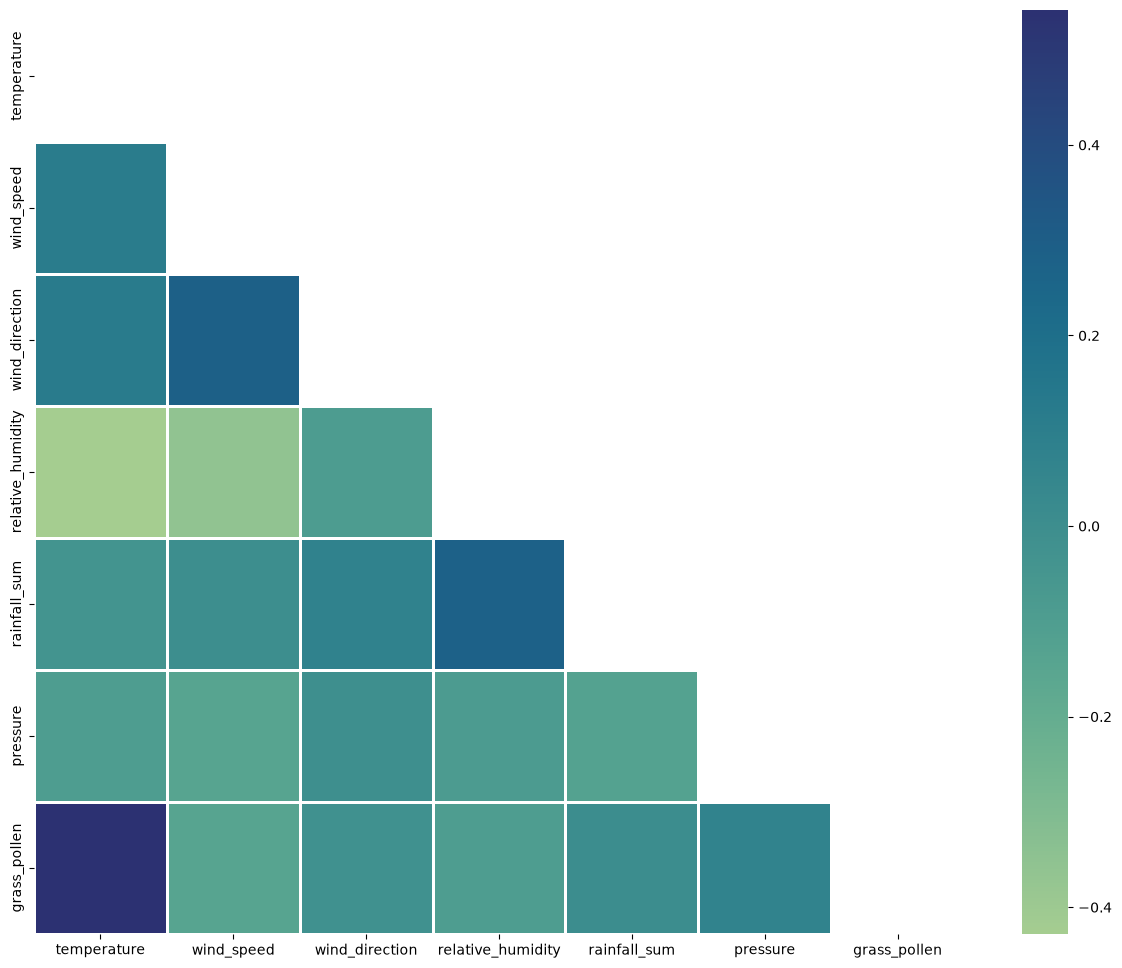

In [173]:
#triangular matrix
num_cols = df_merged.select_dtypes(['int', 'float']).columns
corr_data = df_merged[num_cols]

corr_coef = corr_data.corr()
plt.figure(figsize=(15, 12))
matrix = np.triu(corr_coef)
sns.heatmap(corr_coef,linewidth=.8, mask = matrix, cmap="crest");

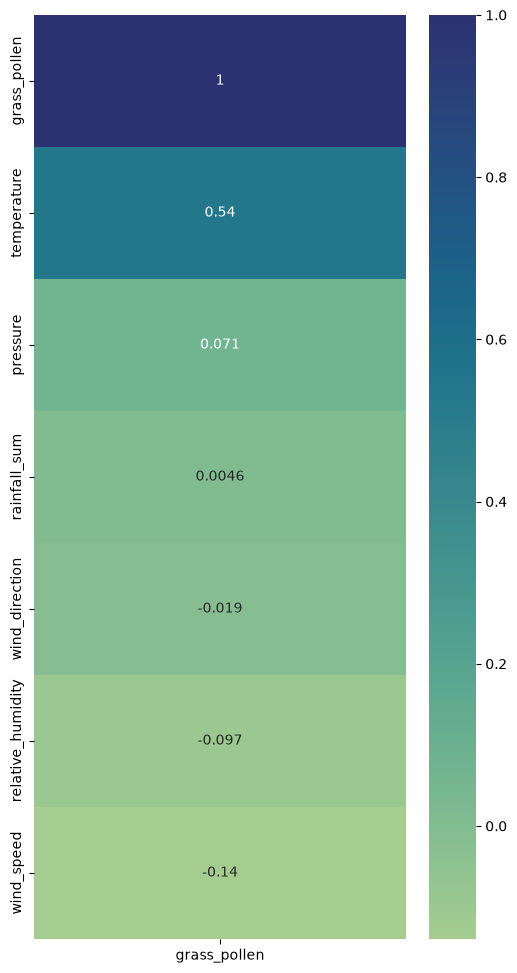

In [174]:
plt.figure(figsize=(6,12))
sns.heatmap(corr_coef[['grass_pollen']].sort_values(by=['grass_pollen'], ascending=False),
            cmap='crest',
            annot=True);

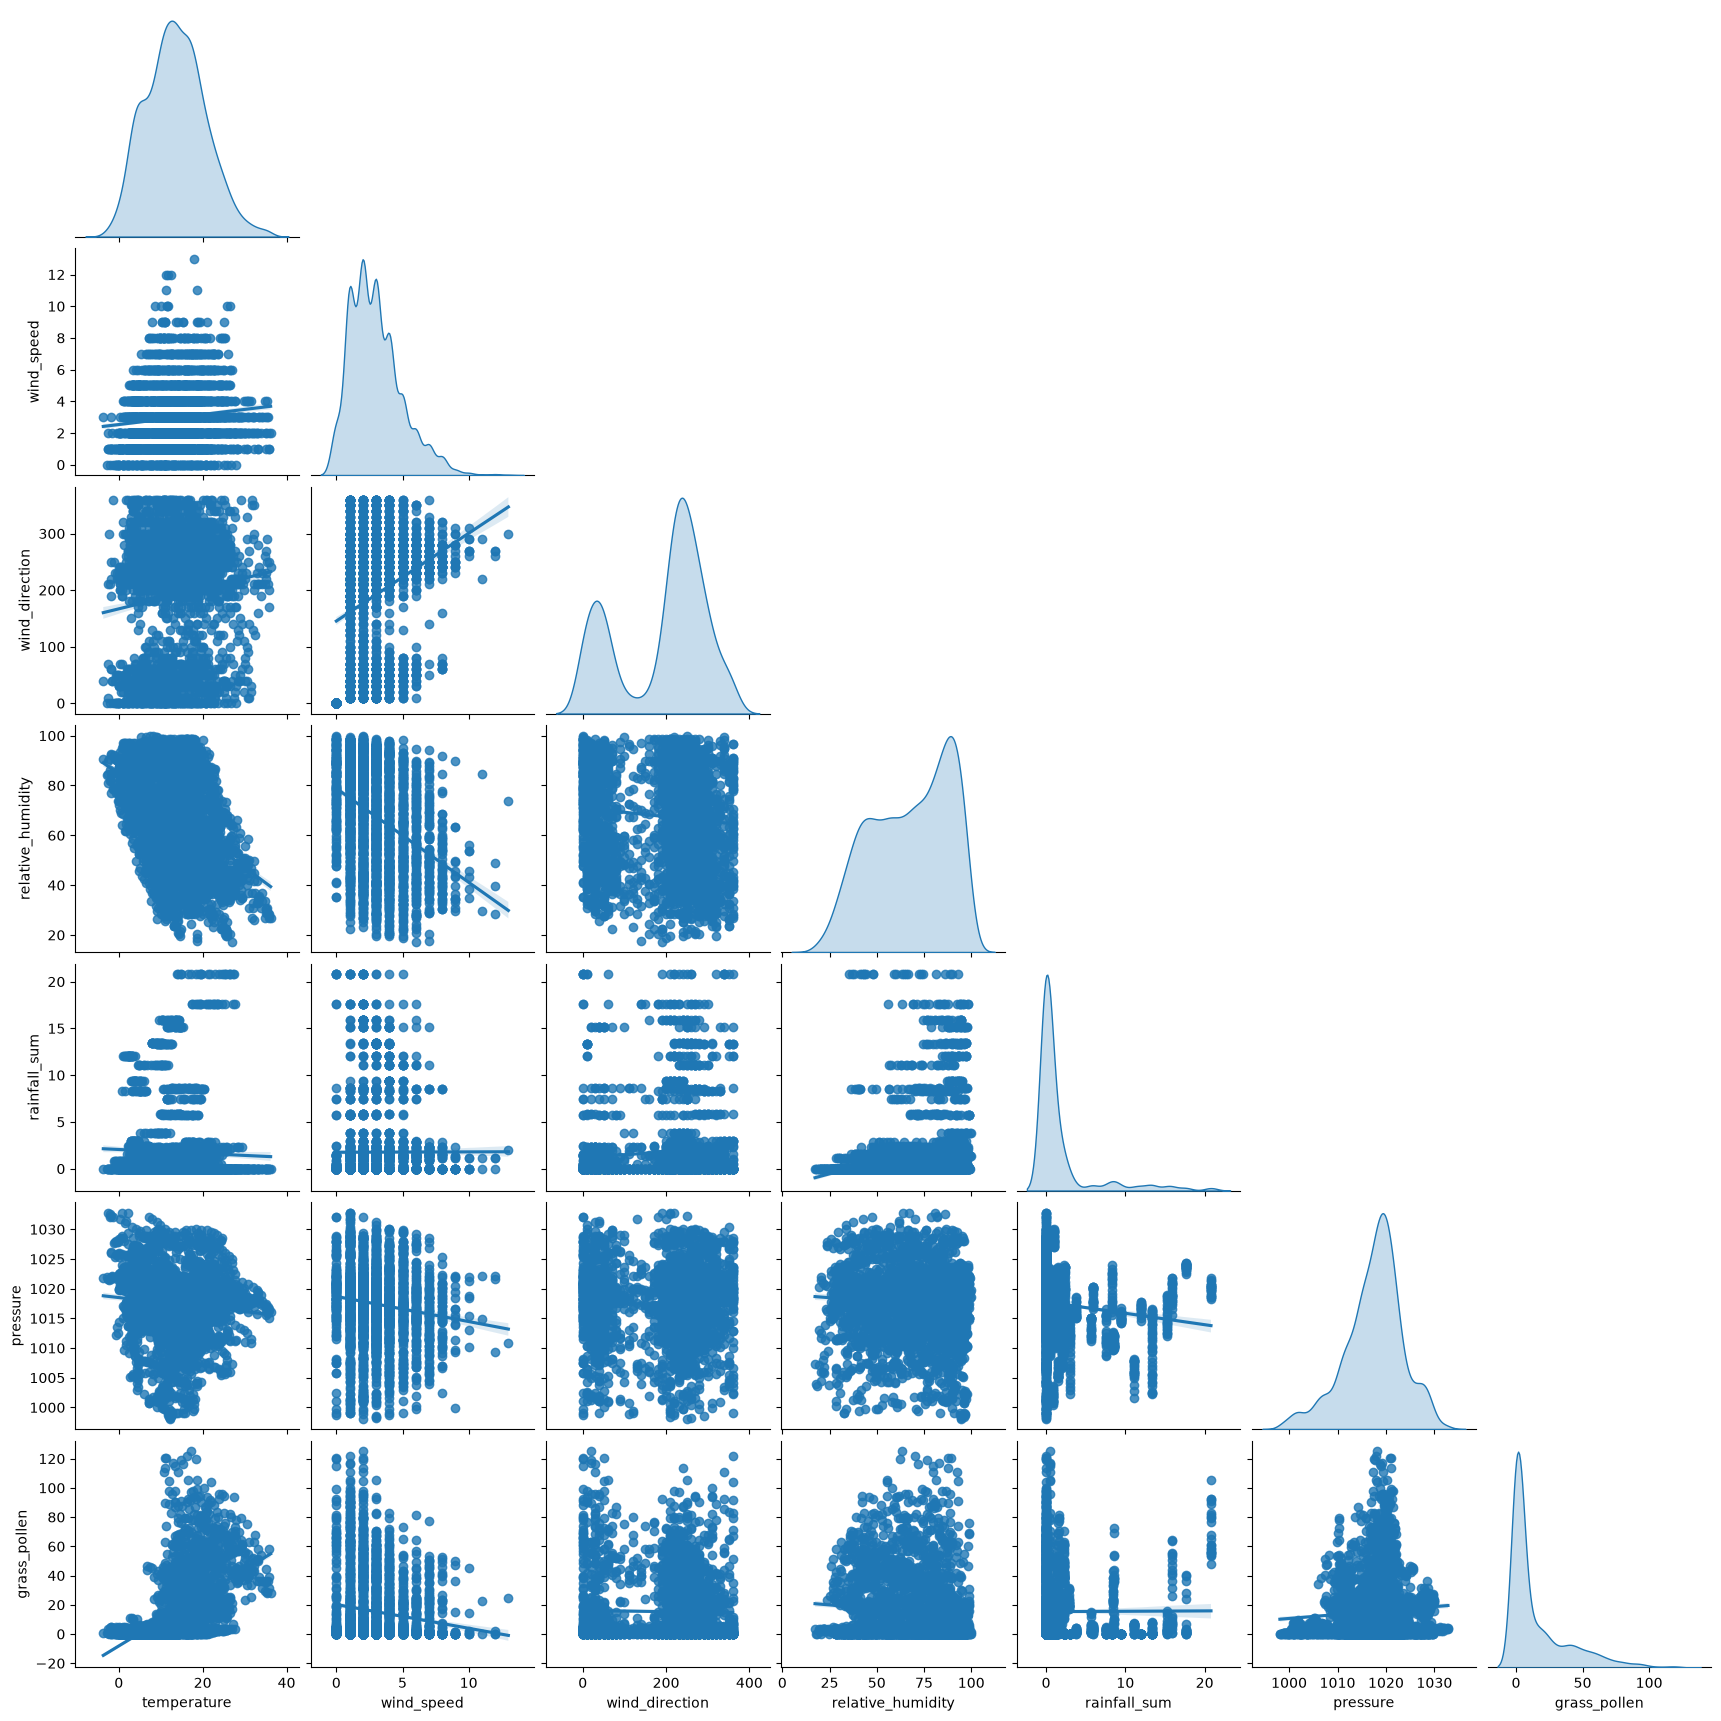

In [175]:
sns.pairplot(corr_data, corner=True, kind='reg', diag_kind='kde')

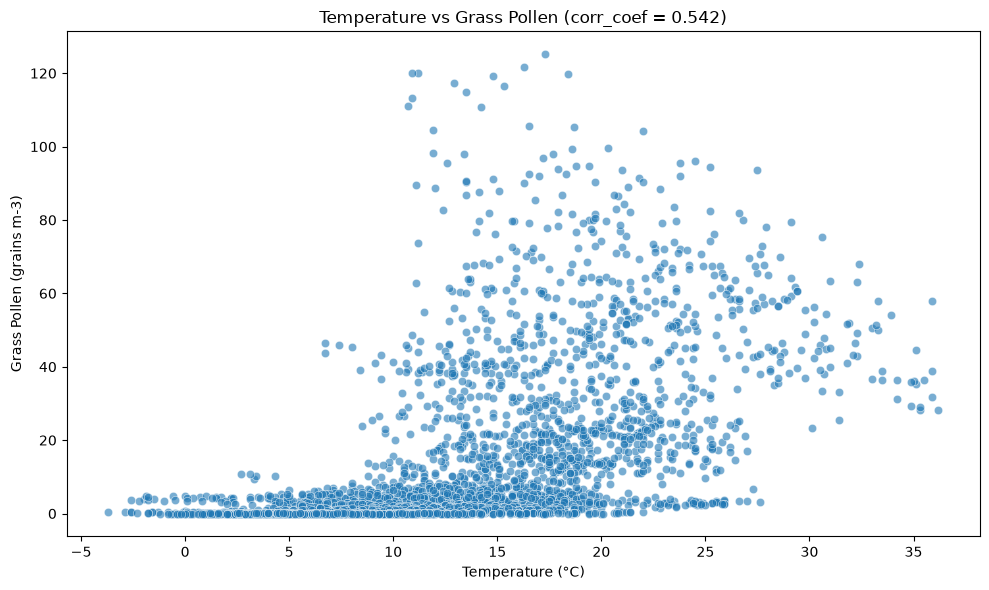

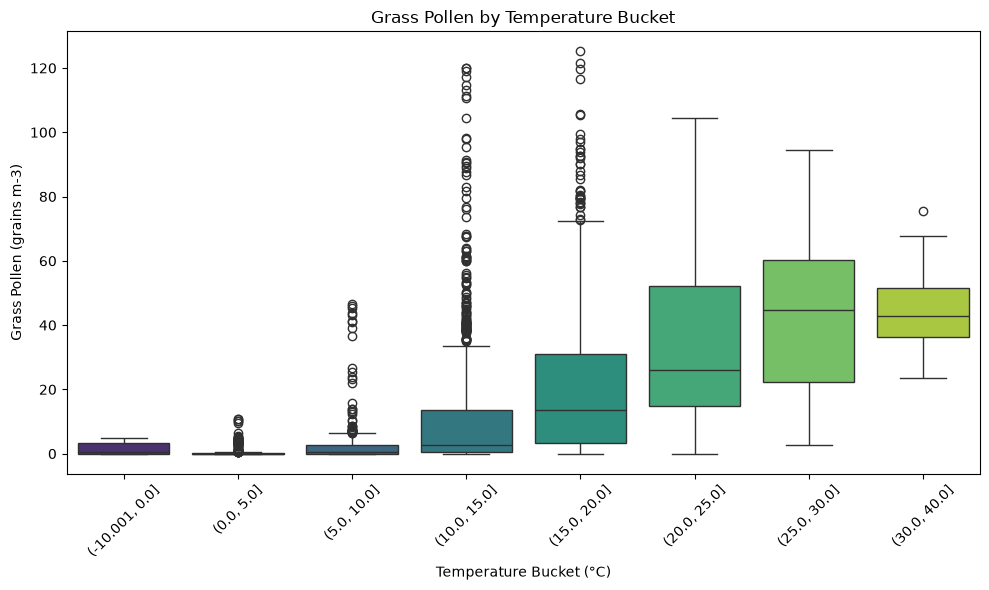

In [176]:
scatter_df = df_merged.dropna(subset=['temperature', 'grass_pollen']).copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_df, x='temperature', y='grass_pollen', alpha=0.6)
#sns.regplot(data=scatter_df, x='temperature', y='grass_pollen', scatter=False, color='black')
plt.title(f'Temperature vs Grass Pollen (corr_coef = {scatter_df[["temperature", "grass_pollen"]].corr().iloc[0, 1]:.3f})')
plt.xlabel('Temperature (°C)')
plt.ylabel('Grass Pollen (grains m-3)')
plt.tight_layout()
plt.show()

bucket_df = df_merged.dropna(subset=['temperature', 'grass_pollen']).copy()
bucket_df['temperature_bucket'] = pd.cut(
    bucket_df['temperature'],
    bins=[-10, 0, 5, 10, 15, 20, 25, 30, 40],
    right=True,
    include_lowest=True
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=bucket_df, x='temperature_bucket', y='grass_pollen', hue='temperature_bucket', dodge=False, legend=False, palette='viridis')
plt.title('Grass Pollen by Temperature Bucket')
plt.xlabel('Temperature Bucket (°C)')
plt.ylabel('Grass Pollen (grains m-3)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

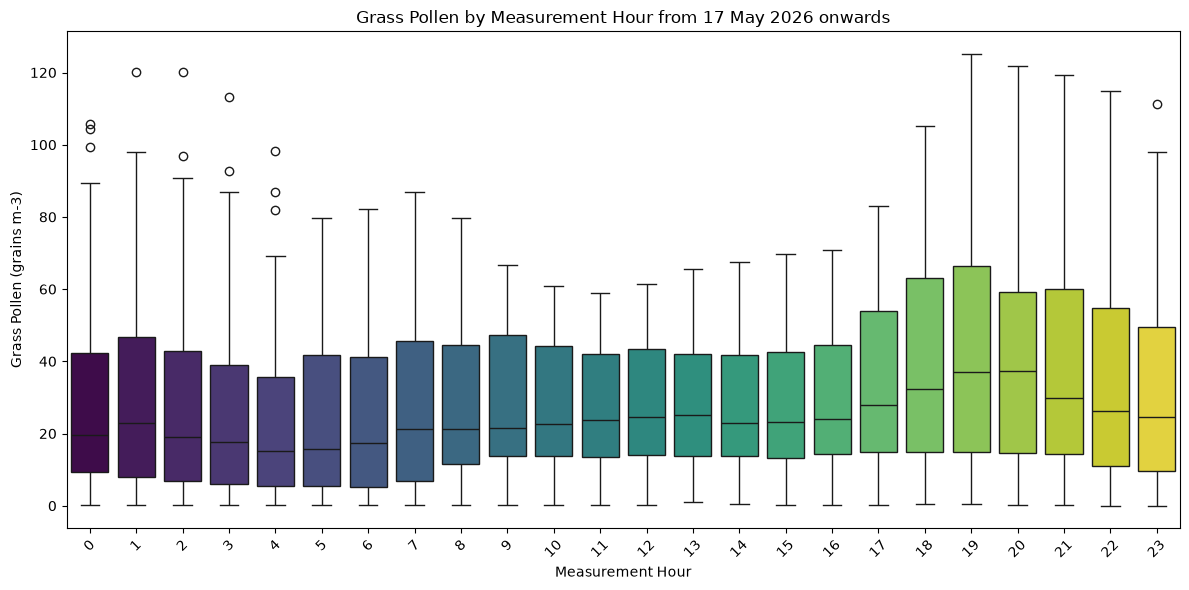

In [177]:
df_merged_from_date = df_merged[df_merged['date'] >= '2026-05-17'].copy()
hourly_df = df_merged_from_date.dropna(subset=['measurement_hour', 'grass_pollen']).copy()
hourly_df['measurement_hour'] = hourly_df['measurement_hour'].apply(lambda h: h.hour)

plt.figure(figsize=(12, 6))
sns.boxplot(data=hourly_df, x='measurement_hour', y='grass_pollen', hue='measurement_hour', dodge=False, legend=False, palette='viridis')
plt.title('Grass Pollen by Measurement Hour from 17 May 2026 onwards')
plt.xlabel('Measurement Hour')
plt.ylabel('Grass Pollen (grains m-3)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

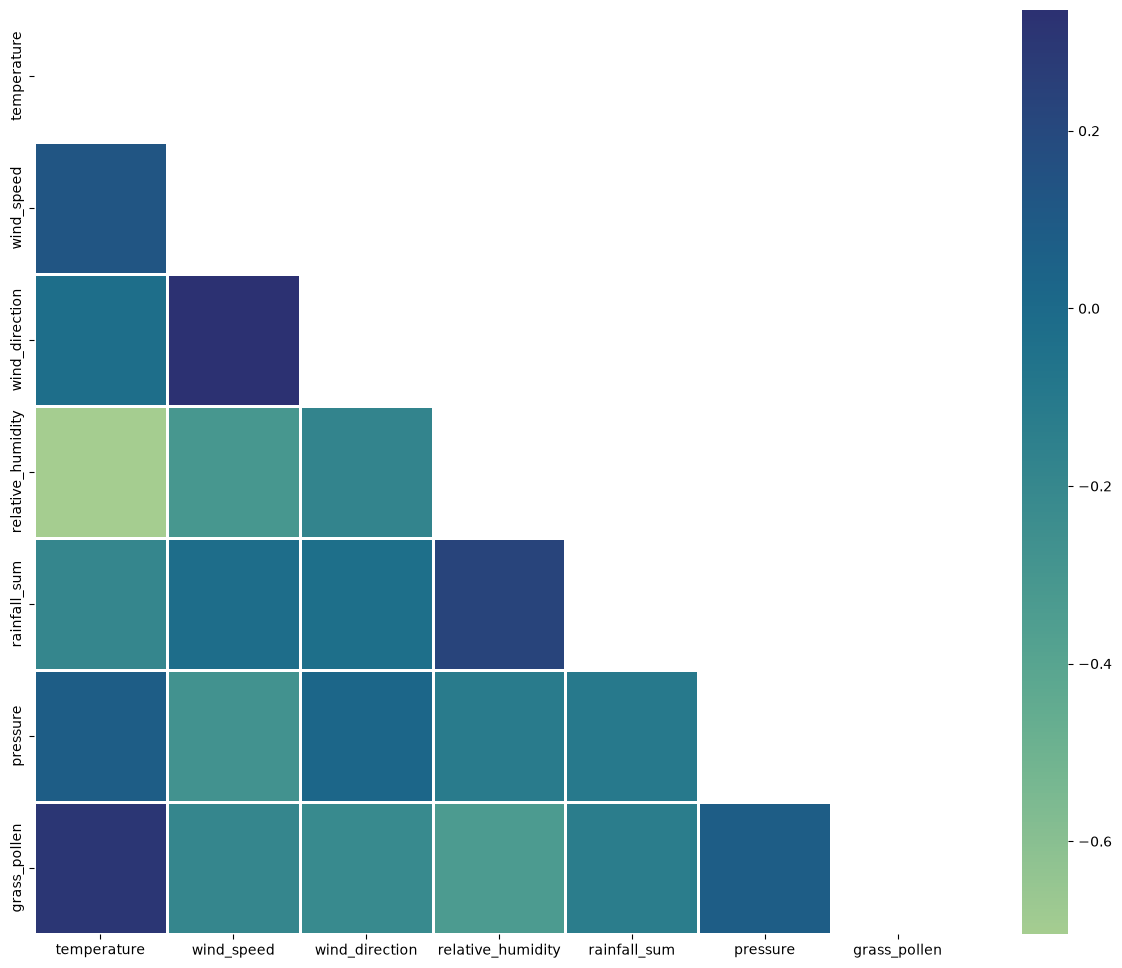

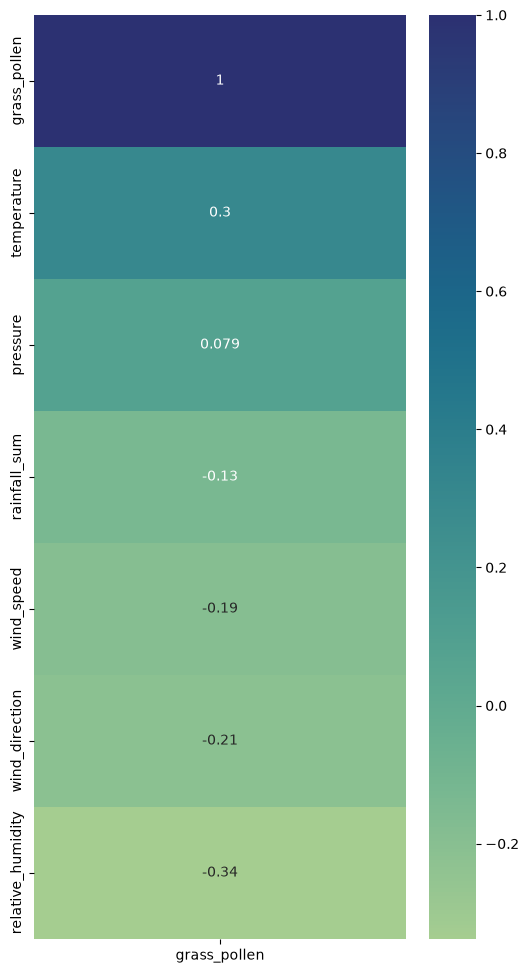

In [178]:
#triangular matrix from 17 May 2026 onwards
num_cols = df_merged.select_dtypes(['int', 'float']).columns
corr_data = df_merged_from_date[num_cols]

corr_coef = corr_data.corr()
plt.figure(figsize=(15, 12))
matrix = np.triu(corr_coef)
sns.heatmap(corr_coef,linewidth=.8, mask = matrix, cmap="crest");

plt.figure(figsize=(6,12))
sns.heatmap(corr_coef[['grass_pollen']].sort_values(by=['grass_pollen'], ascending=False),
            cmap='crest',
            annot=True);

In [179]:
df_merged_from_date_range_1 = df_merged[(df_merged['date'] >= '2026-05-28') & (df_merged['date'] < '2026-06-05')].copy()
plot_df_1 = df_merged_from_date_range_1.sort_values(['date', 'measurement_hour'])
plot_df_1.head(60)

,date,date_24h_ahead,measurement_hour,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,grass_pollen
1140,2026-05-28,2026-05-29 00:00:00,00:00:00,12.300,3.000,310,46.600,0.000,1020.100,40.535
1141,2026-05-28,2026-05-29 01:00:00,01:00:00,11.700,3.000,310,48.500,0.000,1020.100,40.131
1142,2026-05-28,2026-05-29 02:00:00,02:00:00,8.400,2.000,270,64.700,0.000,1020.600,39.185
1143,2026-05-28,2026-05-29 03:00:00,03:00:00,9.400,1.000,230,61.700,0.000,1020.800,36.672
1144,2026-05-28,2026-05-29 04:00:00,04:00:00,10.400,3.000,260,60.700,0.000,1021.200,32.948
1145,2026-05-28,2026-05-29 05:00:00,05:00:00,12.200,4.000,290,54.500,0.000,1021.400,28.696
1146,2026-05-28,2026-05-29 06:00:00,06:00:00,13.400,4.000,280,54.400,0.000,1021.700,24.191
1147,2026-05-28,2026-05-29 07:00:00,07:00:00,14.300,5.000,270,47.400,0.000,1021.800,21.653
1148,2026-05-28,2026-05-29 08:00:00,08:00:00,15.600,5.000,290,39.400,0.000,1021.700,19.689
1149,2026-05-28,2026-05-29 09:00:00,09:00:00,16.700,5.000,300,39.400,0.000,1021.700,18.272


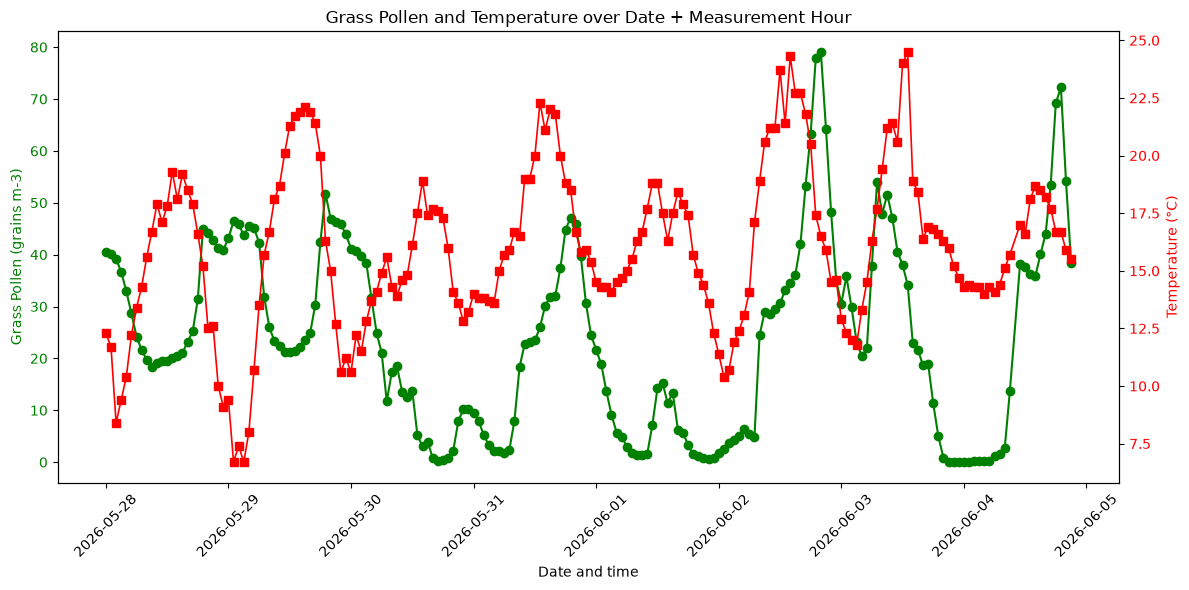

In [180]:
data_1 = plot_df_1['grass_pollen']
data_2 = plot_df_1['temperature']
x = pd.to_datetime(
    plot_df_1['date'].astype(str)
    + ' '    
    + plot_df_1['measurement_hour'].astype(str)
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x, data_2, color='red', marker='s', linewidth=1.2)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date + Measurement Hour')
plt.tight_layout()
plt.show()

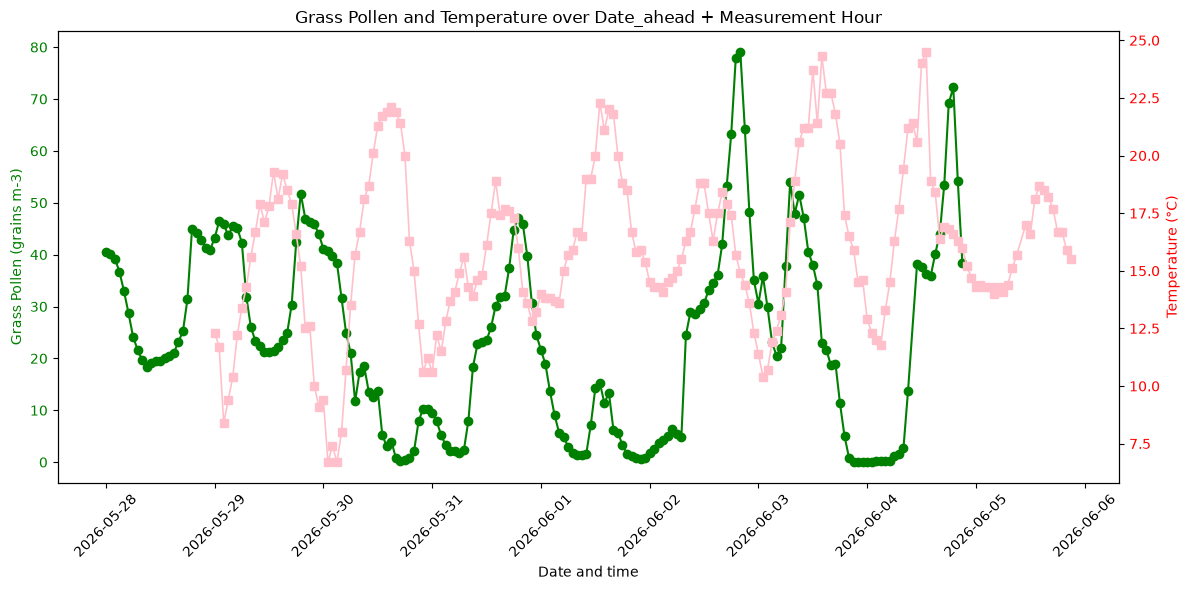

In [189]:
data_1 = plot_df_1['grass_pollen']
data_2 = plot_df_1['temperature']
x = pd.to_datetime(
    plot_df_1['date'].astype(str)
    + ' '    
    + plot_df_1['measurement_hour'].astype(str)
)
x_ahead = plot_df_1['date_24h_ahead']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x_ahead, data_2, color='pink', marker='s', linewidth=1.2)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date_ahead + Measurement Hour')
plt.tight_layout()
plt.show()

In [183]:
df_merged_from_date_range_2 = df_merged[(df_merged['date'] >= '2026-07-02') & (df_merged['date'] < '2026-07-09')].copy()
plot_df_2 = df_merged_from_date_range_2.sort_values(['date', 'measurement_hour'])
plot_df_2[50:100]

,date,date_24h_ahead,measurement_hour,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,grass_pollen
282,2026-07-04,2026-07-05 23:00:00,23:00:00,12.200,2.000,220,71.700,0.100,1019.200,45.742
253,2026-07-05,2026-07-06 00:00:00,00:00:00,11.400,2.000,250,76.700,0.100,1019.000,38.463
254,2026-07-05,2026-07-06 01:00:00,01:00:00,11.200,2.000,250,82.700,0.100,1018.500,35.792
255,2026-07-05,2026-07-06 02:00:00,02:00:00,12.800,3.000,230,77.900,0.100,1017.900,33.288
256,2026-07-05,2026-07-06 03:00:00,03:00:00,13.200,3.000,230,79.600,0.100,1017.700,26.512
257,2026-07-05,2026-07-06 04:00:00,04:00:00,12.600,3.000,220,94.200,0.100,1017.300,20.931
258,2026-07-05,2026-07-06 05:00:00,05:00:00,13.200,3.000,210,94.200,0.100,1016.900,18.963
259,2026-07-05,2026-07-06 06:00:00,06:00:00,13.200,4.000,230,94.200,0.900,1016.600,15.270
260,2026-07-05,2026-07-06 07:00:00,07:00:00,13.600,4.000,220,96.100,0.900,1016.200,14.845
261,2026-07-05,2026-07-06 08:00:00,08:00:00,16.400,7.000,240,88.900,0.900,1015.600,15.682


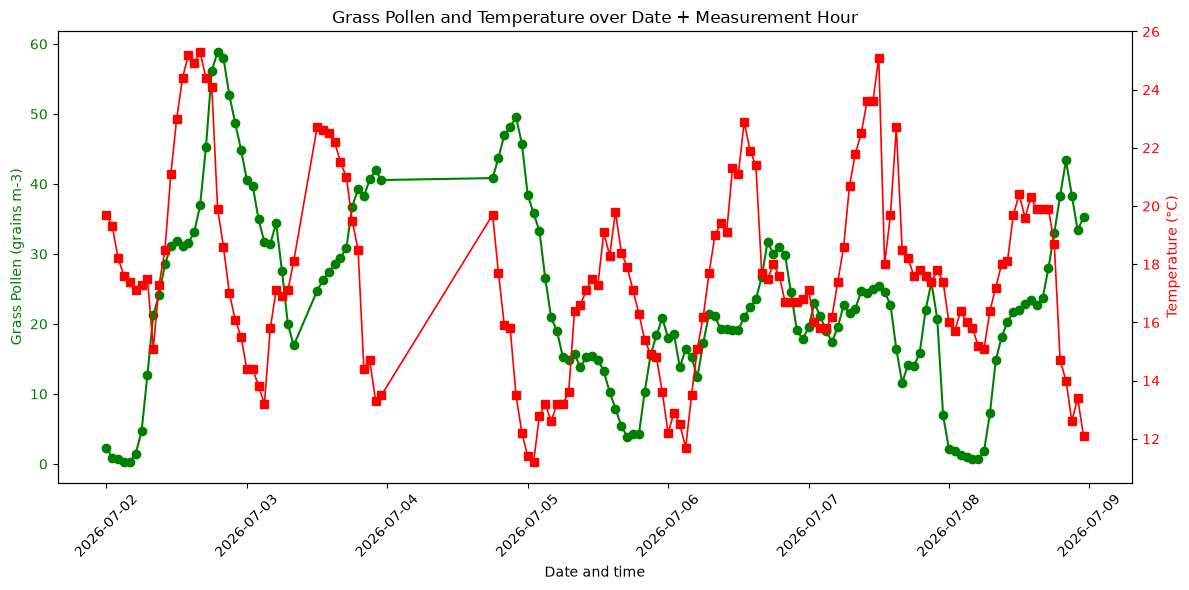

In [184]:
data_1 = plot_df_2['grass_pollen']
data_2 = plot_df_2['temperature']
x = pd.to_datetime(
    plot_df_2['date'].astype(str)
    + ' '    
    + plot_df_2['measurement_hour'].astype(str)
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x, data_2, color='red', marker='s', linewidth=1.2)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date + Measurement Hour')
plt.tight_layout()
plt.show()

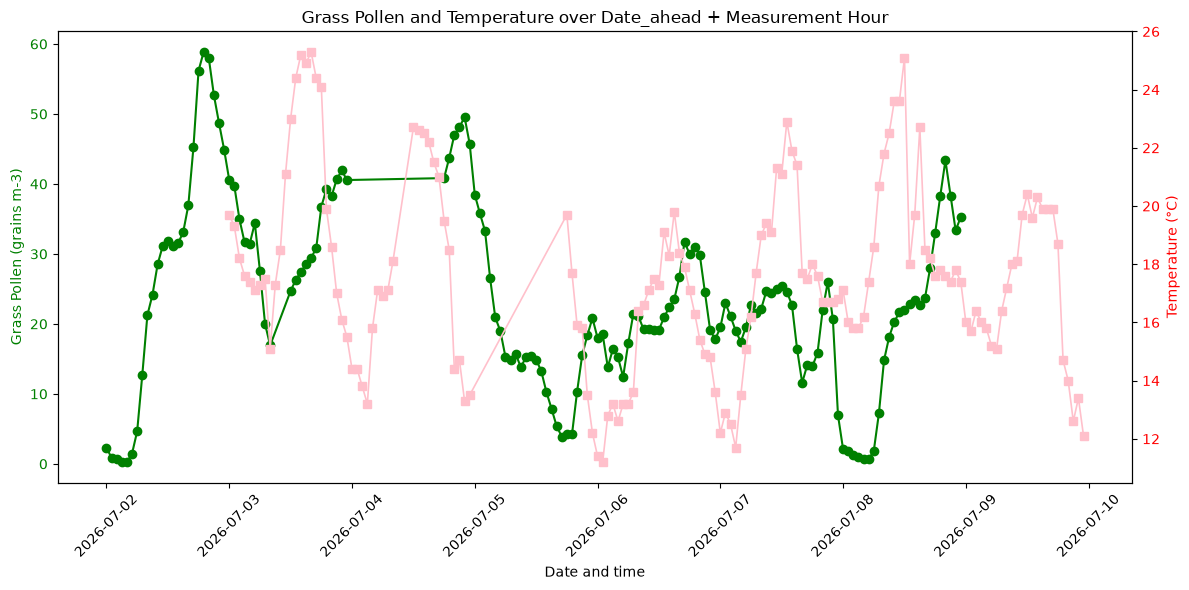

In [185]:
data_1 = plot_df_2['grass_pollen']
data_2 = plot_df_2['temperature']
x = pd.to_datetime(
    plot_df_2['date'].astype(str)
    + ' '    
    + plot_df_2['measurement_hour'].astype(str)
)

x_ahead = plot_df_2['date_24h_ahead']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x_ahead, data_2, color='pink', marker='s', linewidth=1.2)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date_ahead + Measurement Hour')
plt.tight_layout()
plt.show()

In [186]:
df_merged_from_date_range_3 = df_merged[(df_merged['date'] >= '2026-06-28') & (df_merged['date'] < '2026-07-02')].copy()
plot_df_3 = df_merged_from_date_range_3.sort_values(['date', 'measurement_hour'])
plot_df_3[20:70]


,date,date_24h_ahead,measurement_hour,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,grass_pollen
420,2026-06-28,2026-06-29 20:00:00,20:00:00,26.400,1.000,290,65.000,0.000,1017.800,63.685
421,2026-06-28,2026-06-29 21:00:00,21:00:00,25.800,0.000,0,68.300,0.000,1018.200,65.491
422,2026-06-28,2026-06-29 22:00:00,22:00:00,25.300,1.000,40,70.500,0.000,1018.400,67.530
423,2026-06-28,2026-06-29 23:00:00,23:00:00,23.700,0.000,0,78.300,0.000,1018.300,71.064
376,2026-06-29,2026-06-30 00:00:00,00:00:00,22.700,0.000,0,83.800,0.000,1018.200,66.219
377,2026-06-29,2026-06-30 01:00:00,01:00:00,21.400,1.000,20,87.500,0.000,1018.200,63.154
378,2026-06-29,2026-06-30 02:00:00,02:00:00,20.800,0.000,0,88.600,0.000,1018.200,62.713
379,2026-06-29,2026-06-30 03:00:00,03:00:00,20.600,0.000,0,88.600,0.000,1018.300,58.815
380,2026-06-29,2026-06-30 04:00:00,04:00:00,22.200,1.000,270,79.600,0.000,1018.300,56.225
381,2026-06-29,2026-06-30 05:00:00,05:00:00,26.800,0.000,0,59.900,0.000,1017.900,50.333


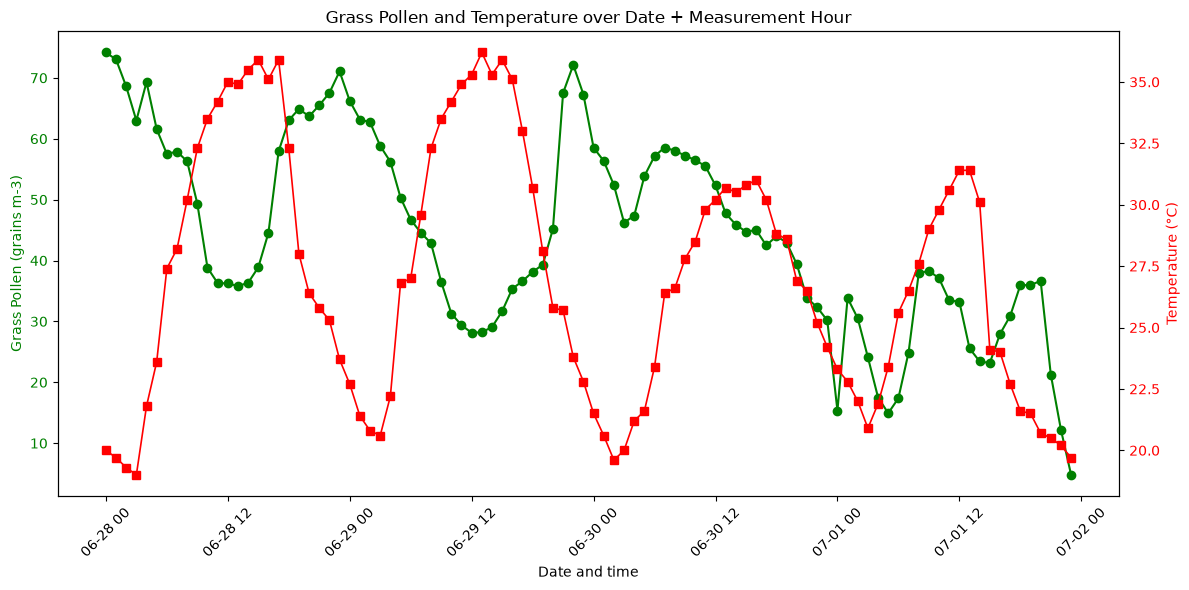

In [187]:
data_1 = plot_df_3['grass_pollen']
data_2 = plot_df_3['temperature']
x = pd.to_datetime(
    plot_df_3['date'].astype(str)
    + ' '    
    + plot_df_3['measurement_hour'].astype(str)
)

x_ahead = plot_df_3['date_24h_ahead']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x, data_2, color='red', marker='s', linewidth=1.2)
ax2.tick_params(axis='y', labelcolor='red')
#ax2.plot(x_ahead, data_2, color='pink', marker='s', linewidth=1.2)

plt.title('Grass Pollen and Temperature over Date + Measurement Hour')
plt.tight_layout()
plt.show()

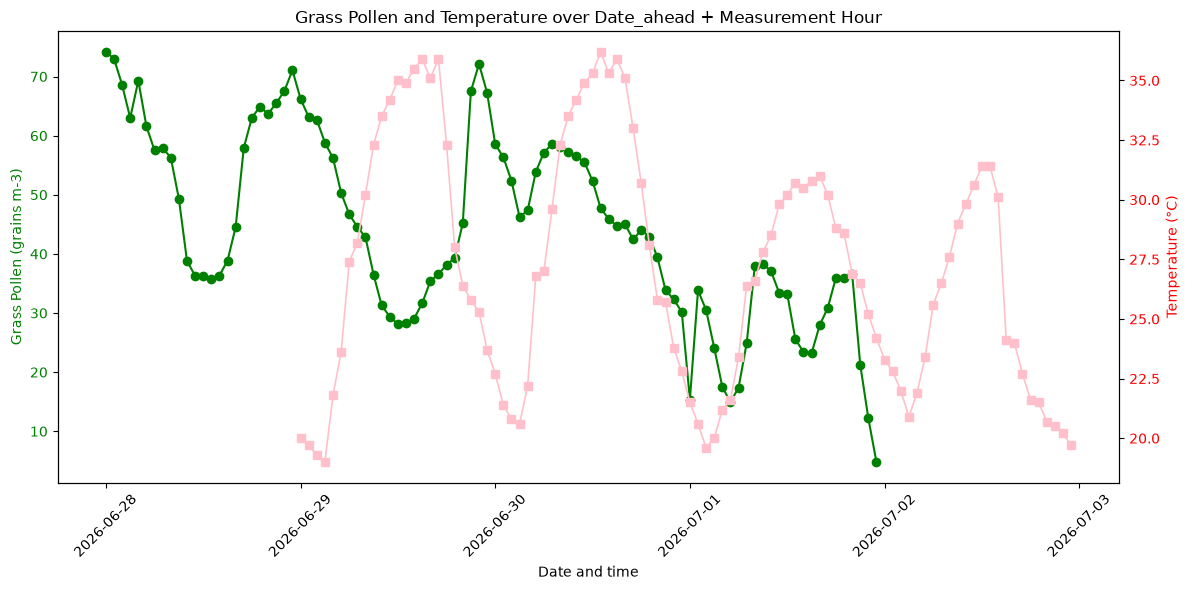

In [188]:
data_1 = plot_df_3['grass_pollen']
data_2 = plot_df_3['temperature']
x = pd.to_datetime(
    plot_df_3['date'].astype(str)
    + ' '    
    + plot_df_3['measurement_hour'].astype(str)
)

x_ahead = plot_df_3['date_24h_ahead']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x_ahead, data_2, color='pink', marker='s', linewidth=1.2)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date_ahead + Measurement Hour')
plt.tight_layout()
plt.show()